# Introduction to Portfolio Construction and Analysis with Python

Note del corso "Introduction to Portfolio Construction and Analysis with Python" di EDHEC Business School, frequentato sulla piattaforma Coursera dal sottoscritto Samuele Voltan (matr. 5485) nell'ambito del progetto pilota BPS.

Il corso si sviluppa in 4 moduli, ognuno dei quali è suddiviso tra lezioni teoriche fornite tramite video-registrazioni e sessioni di laboratorio di programmazione Python, fornite mediante Jupyter Notebooks. Al termine di ogni modulo è stato somministrato un test pratico atto a verificare l'idoneità del sottoscritto a procedere ai moduli successivi. Ogni test intermedio è stato superato dal sottoscritto con il punteggio di 100% al primo tentativo.

L'obbiettivo di queste note è quello di fornire un breve riassunto dei fondamenti teorici del corso affiancandovi esempi pratici ottenuti mediante codice Python sviluppato dal sottoscritto durante le sessioni di laboratorio previste dal corso.

## Module 1: Analysing returns

### Section 1.1: Fundamentals of risk and returns

La formula per il rendimento di un titolo acquistato al tempo $t-1$ al prezzo $P_{t-1}$ e venduto al tempo $t$ al prezzo $P_t$ è la seguente:

\begin{equation}
R_{t}=\frac{P_{t} - P_{t-1}}{P_{t-1}}=\frac{P_t}{P_{t-1}}-1.
\end{equation}

Spesso conviene esprimere il rendimento in termini del rapporto $r_t=P_{t}/P_{t-1}$ al fine di poter generalizzare facilmente la formula ed introdurre così il rendimento composto. Difatti, per conoscere il rendimento al tempo $t$ di un titolo acquistato al tempo $t=0$ è sufficiente conoscere la sequenza dei rapporti $r_t, \dots, r_0$ ed esprimere il rendimento come


In [1]:
from portfolio import Tickers
aapl_meta = Tickers(['AAPL', 'META'], period='1y')

[*********************100%***********************]  2 of 2 completed


In [8]:
aapl_meta.df.columns.values

array(['AAPL', 'META'], dtype=object)

In [1]:
from portfolio import Portfolio, Tickers, efficient_frontier
%load_ext autoreload
%autoreload 2

In [2]:
sp_500 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'JPM', 'JNJ', 'V', 'PG', 'TSLA']
p = Tickers(sp_500, period="1y")

[*********************100%***********************]  10 of 10 completed


In [34]:
p.ptf_return, p.ptf_volatility

(0.38960980985598365, 0.011011951460849894)

In [2]:
p = Portfolio(sp_500, "1y")


NameError: name 'sp_500' is not defined

[*********************100%***********************]  10 of 10 completed


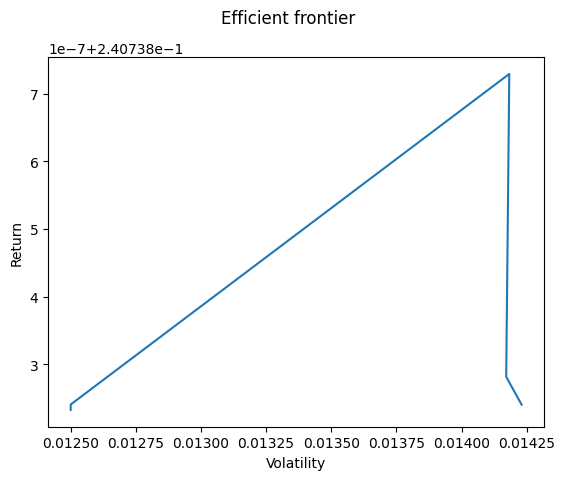

In [26]:
# def frontier(n_samples: int, tickers: list):

#     # definizione della griglia dei rendimenti
#     import numpy as np
#     aa = Portfolio(tickers)
#     ptfs = [aa.copy() for _ in range(n_samples)]
#     min_return = aa.annual_returns.min()
#     max_return = aa.annual_returns.max()
#     target_returns = np.linspace(min_return, max_return, n_samples)

#     # definizione dei portafoglio sulla frontiera efficiente
#     for tr, ptf in zip(target_returns, ptfs):
#         ptf.minimize_vol(tr)
    
#     return ptfs

def plot_efficient_frontier(ptfs: list[Portfolio]):
    returns = [ptf.ptf_return for ptf in ptfs]
    volatilities = [ptf.ptf_volatility for ptf in ptfs]
    from matplotlib import pyplot as plt

    fig, ax = plt.subplots()
    ax.plot(volatilities, returns, label='Efficient frontier')
    ax.set_xlabel('Volatility')
    ax.set_ylabel('Return')
    
    fig.suptitle('Efficient frontier')

sp_500 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'JPM', 'JNJ', 'V', 'PG', 'TSLA']
from portfolio import efficient_frontier
plot_efficient_frontier(efficient_frontier(sp_500))

In [13]:
[(aaa.ptf_return, aaa.ptf_volatility) for aaa in aa]

[(-0.6018266039772098, 0.01551207405426504),
 (-0.5607419997960535, 0.017391660949425035),
 (-0.5196573937081468, 0.02056407178298775),
 (-0.47857278752681615, 0.024532793980660543),
 (-0.437488181392958, 0.028972412165182378),
 (-0.39640357527999365, 0.033697316018021124),
 (-0.3553189691690412, 0.03292586531814272),
 (-0.3142343630650607, 0.03171021636112898),
 (-0.27314975696408716, 0.030503466045961384),
 (-0.23206515087465804, 0.029312643946388106),
 (-0.1909805448280659, 0.02819073202680304),
 (-0.14989593870339663, 0.02317071059095789),
 (-0.10881133253028655, 0.022751794379033727),
 (-0.06772672641673497, 0.021246266428695548),
 (-0.026642120309419797, 0.01986181128472237),
 (0.014442485807852155, 0.018100370822665662),
 (0.05552709191097026, 0.016471323155174057),
 (0.09661169802946924, 0.014650907651958799),
 (0.13769630888491752, 0.014864176261211778),
 (0.17878091025474502, 0.014271445794630766),
 (0.21986551639168225, 0.013647091125675075),
 (0.26095012251783767, 0.0135241

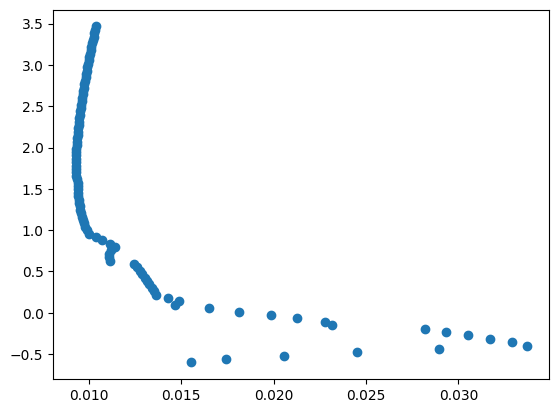

In [21]:
from matplotlib import pyplot as plt
rr = [aaa.ptf_return for aaa in aa]
vv = [aaa.ptf_volatility for aaa in aa]
plt.scatter(x=vv, y=rr)

In [22]:
rr, vv

([-0.6018266039772098,
  -0.5607419997960535,
  -0.5196573937081468,
  -0.47857278752681615,
  -0.437488181392958,
  -0.39640357527999365,
  -0.3553189691690412,
  -0.3142343630650607,
  -0.27314975696408716,
  -0.23206515087465804,
  -0.1909805448280659,
  -0.14989593870339663,
  -0.10881133253028655,
  -0.06772672641673497,
  -0.026642120309419797,
  0.014442485807852155,
  0.05552709191097026,
  0.09661169802946924,
  0.13769630888491752,
  0.17878091025474502,
  0.21986551639168225,
  0.26095012251783767,
  0.30203472860981073,
  0.3431193394559203,
  0.38420394081103215,
  0.4252885469614409,
  0.46637315306291305,
  0.5074577590443037,
  0.548542365209074,
  0.5896269713884911,
  0.6307115774993818,
  0.6717961836528009,
  0.7128807897194034,
  0.7539653957613942,
  0.7950500019726023,
  0.8361346080402584,
  0.8772192141816413,
  0.9183038203005052,
  0.9593884264269145,
  1.0004730372812067,
  1.0415576386714946,
  1.082642244774271,
  1.123726850933725,
  1.1648114570112762,
 